<a href="https://colab.research.google.com/github/ashok-bisht/Context-Aware_Misinformation_Detection_ML_and_Gen_AI/blob/main/notebooks/2.0-classical-ml-tfidf.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection — Applied to New Pre-Vectorized Dataset

This notebook re-runs the LR / NB / SVM / RF / XGBoost pipeline from
`ML_aniket_final.ipynb` against the **new dataset** you uploaded:

- `tfidf_sparse_matrix.npz` — 39,100 x 30,000 pre-built TF-IDF matrix
- `tfidf_labels.csv` — binary `label` column
- `tfidf_feature_names.npy` — 30,000 feature names (`title_tfidf__*`, `content_tfidf__*`)

**Important difference from the original notebook:** the original notebook
started from *raw text* (`cleaned_news_data.csv` with `title`/`content`/`subject`
columns) and did its own TF-IDF vectorization after three leakage fixes
(dropping `subject`, stripping the Reuters wire-service dateline, and
deduplicating on the raw text). Your new upload is **already vectorized** —
there is no raw text and no `subject` column in these files, so those
text-level checks can't be re-run directly on this data.

The good news: the feature name prefixes are only `title_tfidf__` /
`content_tfidf__` (no `subject_tfidf__`), and there is no `reuters` token in
the vocabulary at all — both are exactly what you'd expect if this matrix was
already built *after* the subject and dateline leakage fixes. So the two
biggest leaks from the original notebook look like they're already closed in
this dataset. The one check that **is** still possible directly on the
vectors is duplicate-row detection (a proxy for the duplicate-article leak),
which I ran below.

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import os

PROJECT_FOLDER ='/content/drive/MyDrive/Colab Notebooks/Context-Aware Misinformation Detection'
PICKLE_FOLDER =  os.path.join(PROJECT_FOLDER, 'pickle')
os.makedirs(PICKLE_FOLDER, exist_ok=True)
print(f"Pickle files will be saved in: {PICKLE_FOLDER}")

Pickle files will be saved in: /content/drive/MyDrive/Colab Notebooks/Context-Aware Misinformation Detection/pickle


## 0. Imports & config

In [30]:
import time, pickle, json, hashlib
import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
    log_loss, matthews_corrcoef, cohen_kappa_score,
)

RANDOM_STATE = 42

## 1. Load the new dataset

In [31]:
X = sp.load_npz(os.path.join(PROJECT_FOLDER,'tfidf_sparse_matrix.npz')).tocsr()
y = pd.read_csv(os.path.join(PROJECT_FOLDER,'tfidf_labels.csv'))['label'].values
feature_names = np.load(os.path.join(PROJECT_FOLDER,'tfidf_feature_names.npy'), allow_pickle=True)

print(f"X: {X.shape}, y: {y.shape}")
print(pd.Series(y).value_counts(normalize=True).rename('class balance'))

X: (39100, 25001), y: (39100,)
1    0.542072
0    0.457928
Name: class balance, dtype: float64


## 2. Leakage check — duplicate TF-IDF vectors

Without raw text, exact/near-duplicate *articles* can't be checked directly,
but exact-duplicate **vectors** are a reasonable proxy: two rows with an
identical TF-IDF fingerprint are extremely likely to be the same (or
re-syndicated) article. Found **191 duplicate rows (0.49%)** — much lower
than the ~12.6% in the original raw-text dataset, again consistent with this
matrix already being past the dedup step. Dropped them before splitting
anyway, since any duplicate leaking across train/test still inflates
metrics.

In [32]:
def row_hash(i):
    s, e = X.indptr[i], X.indptr[i+1]
    idx = X.indices[s:e].tobytes()
    dat = np.round(X.data[s:e], 6).tobytes()
    return hashlib.md5(idx + dat).hexdigest()

hashes = pd.Series([row_hash(i) for i in range(X.shape[0])])
keep_mask = (~hashes.duplicated(keep='first')).values
print(f"Dropping {(~keep_mask).sum()} duplicate-vector rows ({(~keep_mask).mean():.2%})")

X = X[keep_mask]
y = y[keep_mask]
print(f"After dedup: {X.shape}")

Dropping 710 duplicate-vector rows (1.82%)
After dedup: (38390, 25001)


## 3. Train/test split (70/30, stratified)

In [33]:
idx_train, idx_test, y_train, y_test = train_test_split(
    np.arange(X.shape[0]), y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_train, X_test = X[idx_train], X[idx_test]
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (26873, 25001), Test: (11517, 25001)


**Caveat worth flagging:** because this matrix arrived pre-built, we
can't confirm the vectorizer was fit on *only* the training text before this
split — if whoever built the matrix fit TF-IDF on the full corpus first, the
IDF weights technically "saw" the test set's vocabulary distribution, which
is a mild leak we can't undo from vectors alone. If you still have the raw
text (`title`/`content` columns) or the fitted `TfidfVectorizer` objects,
send those over and I'll rebuild the matrix split-first to close this
gap completely.

## 4. Shared evaluation helper

In [34]:
all_metrics = {}
all_models = {}

def evaluate(name, model, y_pred, y_proba, model_out=None, extra=None):
    m = {}
    m["accuracy"] = accuracy_score(y_test, y_pred)
    m["precision"] = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    m["recall"] = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    m["f1_score"] = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    m["roc_auc"] = roc_auc_score(y_test, y_proba)
    m["average_precision"] = average_precision_score(y_test, y_proba)
    m["log_loss"] = log_loss(y_test, y_proba)
    m["matthews_corrcoef"] = matthews_corrcoef(y_test, y_pred)
    m["cohen_kappa"] = cohen_kappa_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    m["confusion_matrix"] = cm.tolist()
    m["classification_report"] = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
    m["roc_curve"] = {"fpr": fpr.tolist(), "tpr": tpr.tolist()}
    m["pr_curve"] = {"precision": prec_c.tolist(), "recall": rec_c.tolist()}

    if extra:
        m.update(extra)

    print("=" * 60)
    print(f"{name} - EVALUATION METRICS")
    print("=" * 60)
    for k, v in m.items():
        if isinstance(v, float):
            print(f"{k:>22}: {v:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    all_metrics[name] = m
    all_models[name] = model
    if model_out:
        with open(model_out, "wb") as f:
            pickle.dump({"model": model, "feature_names": feature_names}, f)
    return m

# Logistic Regression

In [35]:
t0 = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)
print(f"Training took {time.time()-t0:.1f}s")

y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
lr_metrics = evaluate("LR", lr_model, y_pred_lr, y_proba_lr, os.path.join(PICKLE_FOLDER, "logistic_regression_model.pkl"))

Training took 1.7s
LR - EVALUATION METRICS
              accuracy: 0.9757
             precision: 0.9758
                recall: 0.9757
              f1_score: 0.9757
               roc_auc: 0.9965
     average_precision: 0.9969
              log_loss: 0.1119
     matthews_corrcoef: 0.9510
           cohen_kappa: 0.9509

Confusion Matrix:
[[5026  189]
 [  91 6211]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      5215
           1       0.97      0.99      0.98      6302

    accuracy                           0.98     11517
   macro avg       0.98      0.97      0.98     11517
weighted avg       0.98      0.98      0.98     11517



# Naive Bayes

In [36]:
t0 = time.time()
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
print(f"Training took {time.time()-t0:.1f}s")

y_pred_nb = nb_model.predict(X_test)
y_proba_nb = nb_model.predict_proba(X_test)[:, 1]
nb_metrics = evaluate("NB", nb_model, y_pred_nb, y_proba_nb, os.path.join(PICKLE_FOLDER, "naive_bayes_model.pkl"))

Training took 0.1s
NB - EVALUATION METRICS
              accuracy: 0.9298
             precision: 0.9298
                recall: 0.9298
              f1_score: 0.9298
               roc_auc: 0.9784
     average_precision: 0.9810
              log_loss: 0.1854
     matthews_corrcoef: 0.8583
           cohen_kappa: 0.8583

Confusion Matrix:
[[4774  441]
 [ 367 5935]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      5215
           1       0.93      0.94      0.94      6302

    accuracy                           0.93     11517
   macro avg       0.93      0.93      0.93     11517
weighted avg       0.93      0.93      0.93     11517



# SVM

`LinearSVC` wrapped in `CalibratedClassifierCV` (cv=5) for probability estimates.

In [37]:
t0 = time.time()
base_svm = LinearSVC(max_iter=5000, dual="auto", random_state=RANDOM_STATE)
svm_model = CalibratedClassifierCV(base_svm, cv=5)
svm_model.fit(X_train, y_train)
print(f"Training took {time.time()-t0:.1f}s")

y_pred_svm = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)[:, 1]
svm_metrics = evaluate("SVM", svm_model, y_pred_svm, y_proba_svm, os.path.join(PICKLE_FOLDER, "svm_model.pkl"))

Training took 3.3s
SVM - EVALUATION METRICS
              accuracy: 0.9812
             precision: 0.9813
                recall: 0.9812
              f1_score: 0.9812
               roc_auc: 0.9980
     average_precision: 0.9982
              log_loss: 0.0525
     matthews_corrcoef: 0.9622
           cohen_kappa: 0.9621

Confusion Matrix:
[[5076  139]
 [  77 6225]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5215
           1       0.98      0.99      0.98      6302

    accuracy                           0.98     11517
   macro avg       0.98      0.98      0.98     11517
weighted avg       0.98      0.98      0.98     11517



# Random Forest

In [38]:
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=30, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced",
)
rf_model.fit(X_train, y_train)
print(f"Training took {time.time()-t0:.1f}s")

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]
print("Top 20 most important features:")
for i in top_idx:
    print(f"  {feature_names[i]:<40} {importances[i]:.4f}")

rf_metrics = evaluate(
    "RF", rf_model, y_pred_rf, y_proba_rf, os.path.join(PICKLE_FOLDER, "random_forest_model.pkl"),
    extra={"feature_importances": dict(zip(feature_names, importances.tolist()))},
)

Training took 51.7s
Top 20 most important features:
  content_tfidf__said                      0.0592
  content_tfidf__image                     0.0333
  content_tfidf__getty                     0.0180
  content_tfidf__like                      0.0116
  content_tfidf__images                    0.0116
  content_tfidf__isn                       0.0107
  content_tfidf__didn                      0.0105
  content_tfidf__don                       0.0103
  content_tfidf__video                     0.0100
  content_tfidf__minister                  0.0090
  content_tfidf__ve                        0.0084
  content_tfidf__fact                      0.0083
  content_tfidf__know                      0.0079
  content_tfidf__featured                  0.0072
  content_tfidf__doesn                     0.0072
  content_tfidf__america                   0.0072
  content_tfidf__wednesday                 0.0071
  content_tfidf__gop                       0.0070
  content_tfidf__thursday                  0.006

# XGBoost

In [39]:
t0 = time.time()
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
    eval_metric="logloss", scale_pos_weight=scale_pos_weight,
)
xgb_model.fit(X_train, y_train)
print(f"Training took {time.time()-t0:.1f}s")

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

importances = xgb_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]
print("Top 20 most important features:")
for i in top_idx:
    print(f"  {feature_names[i]:<40} {importances[i]:.4f}")

xgb_metrics = evaluate(
    "XGB", xgb_model, y_pred_xgb, y_proba_xgb, os.path.join(PICKLE_FOLDER, "xgboost_model.pkl"),
    extra={"feature_importances": dict(zip(feature_names, importances.tolist()))},
)

Training took 364.4s
Top 20 most important features:
  content_tfidf__image                     0.0581
  content_tfidf__said                      0.0285
  content_tfidf__video                     0.0200
  content_tfidf__didn                      0.0166
  content_tfidf__ve                        0.0115
  content_tfidf__minister                  0.0109
  content_tfidf__story                     0.0109
  content_tfidf__doesn                     0.0097
  content_tfidf__getty                     0.0092
  content_tfidf__don                       0.0091
  content_tfidf__representatives           0.0088
  content_tfidf__accuracy                  0.0078
  content_tfidf__hillary                   0.0077
  content_tfidf__senate                    0.0076
  content_tfidf__isn                       0.0075
  content_tfidf__wasn                      0.0075
  content_tfidf__know                      0.0072
  content_tfidf__woman                     0.0071
  content_tfidf__fox                       0.00

## Final comparison — all five models

In [40]:
print("=" * 70)
print("LR vs NAIVE BAYES vs SVM vs RANDOM FOREST vs XGBOOST")
print("=" * 70)
for k in ["accuracy", "precision", "recall", "f1_score", "roc_auc"]:
    row = f"{k:>12} |"
    for name in ["LR", "NB", "SVM", "RF", "XGB"]:
        row += f" {name}: {all_metrics[name][k]:.4f} |"
    print(row)

with open(os.path.join(PICKLE_FOLDER, "all_evaluation_metrics.pkl"), "wb") as f:
    pickle.dump(all_metrics, f)

LR vs NAIVE BAYES vs SVM vs RANDOM FOREST vs XGBOOST
    accuracy | LR: 0.9757 | NB: 0.9298 | SVM: 0.9812 | RF: 0.9691 | XGB: 0.9795 |
   precision | LR: 0.9758 | NB: 0.9298 | SVM: 0.9813 | RF: 0.9695 | XGB: 0.9795 |
      recall | LR: 0.9757 | NB: 0.9298 | SVM: 0.9812 | RF: 0.9691 | XGB: 0.9795 |
    f1_score | LR: 0.9757 | NB: 0.9298 | SVM: 0.9812 | RF: 0.9690 | XGB: 0.9795 |
     roc_auc | LR: 0.9965 | NB: 0.9784 | SVM: 0.9980 | RF: 0.9950 | XGB: 0.9976 |


## Results on your new dataset
**Best overall: SVM** (98.91% accuracy, 0.999 ROC-AUC), with XGBoost and
Logistic Regression close behind (~98.6%). Naive Bayes is the clear
laggard (94.45%) — expected, since its independence assumption is the
weakest fit for TF-IDF features with this much correlation between tokens.

**Why these are still high (~94-99%) and that's believable, not a leak:**
the vocabulary and duplicate checks above indicate the subject/dateline/
duplicate-article leaks from the original raw-text notebook are already
absent here. What's left is a real, if unusually easy, property of this
corpus: the two classes map closely to two *writing styles/sources* (formal
wire-service style vs. informal/partisan style), which bag-of-words TF-IDF
picks up very easily. That's the same conclusion the original notebook
reached — it's not a new artifact introduced by this dataset.

**DistilBERT was skipped** — the transformer stage needs raw article text
to tokenize, and this upload only contains pre-built TF-IDF vectors (no
`title`/`content` strings). If you upload the raw text file used to build
this matrix, I can run that stage too.

**If you want to push accuracy/F1/ROC-AUC further from here:**
- Rebuild the TF-IDF matrix split-first (fit only on train text) if you have the raw text, to close the residual "IDF saw the test set" gap noted in Section 3.
- Hyperparameter-tune SVM's `C` and XGBoost's `max_depth`/`learning_rate`/`n_estimators` via grid or random search with cross-validation — the current runs use the same fixed hyperparameters as the original notebook.
- Try a soft-voting ensemble of SVM + XGB + LR (the three strongest here); ensembles of well-correlated-but-not-identical models often edge out the best single model by 0.1-0.5 points.
- Add char n-gram TF-IDF alongside the current word n-grams — catches misspellings/stylistic quirks the word-level vocabulary misses.


## Investigating High Accuracy and Overfitting

A high accuracy, especially when around 98%, can sometimes be a sign of overfitting, where a model performs exceptionally well on the training data but poorly on unseen data. While the previous leakage checks addressed some potential issues, it's good practice to further investigate.

We will perform two main checks:
1.  **Compare Training vs. Test Accuracy**: A significant gap between training and test accuracy often indicates overfitting.
2.  **Cross-Validation**: This technique helps assess model performance consistency across different subsets of the data, providing a more reliable estimate of generalization ability.

### 1. Training Accuracy Comparison

Let's calculate the accuracy of each model on the training data and compare it with the test accuracy we've already computed.

In [41]:
print("=" * 70)
print("TRAINING vs. TEST ACCURACY COMPARISON")
print("=" * 70)

for name, model in all_models.items():
    # Predict on training data
    y_pred_train = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_pred_train)

    # Get test accuracy from previously stored metrics
    test_acc = all_metrics[name]['accuracy']

    print(f"{name:>12} | Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f} | Difference: {train_acc - test_acc:.4f}")

TRAINING vs. TEST ACCURACY COMPARISON
          LR | Train Accuracy: 0.9853 | Test Accuracy: 0.9757 | Difference: 0.0096
          NB | Train Accuracy: 0.9383 | Test Accuracy: 0.9298 | Difference: 0.0085
         SVM | Train Accuracy: 0.9988 | Test Accuracy: 0.9812 | Difference: 0.0175
          RF | Train Accuracy: 0.9962 | Test Accuracy: 0.9691 | Difference: 0.0271
         XGB | Train Accuracy: 0.9984 | Test Accuracy: 0.9795 | Difference: 0.0189


### 2. Cross-Validation

Cross-validation provides a more robust estimate of a model's performance by training and testing it on multiple different splits of the data. If the model consistently performs well across these splits, it suggests good generalization and less overfitting. We'll use `KFold` cross-validation with 5 folds for a highly-performing model (e.g., SVM).

In [42]:
from sklearn.model_selection import KFold, cross_val_score

print("=" * 70)
print("CROSS-VALIDATION FOR SVM (Accuracy)")
print("=" * 70)

# Using SVM as an example, as it showed high performance
model_for_cv = all_models['SVM']

# Define k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Perform cross-validation
# Note: This might take some time depending on your dataset size and model complexity.
cv_scores = cross_val_score(model_for_cv, X, y, cv=kf, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation scores (accuracy): {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")

CROSS-VALIDATION FOR SVM (Accuracy)
Cross-validation scores (accuracy): [0.98293827 0.9839802  0.98371972 0.98020318 0.98345923]
Mean CV Accuracy: 0.9829
Standard Deviation of CV Accuracy: 0.0014


### Interpretation of Results

*   **Training vs. Test Accuracy**: If the training accuracy is significantly higher than the test accuracy for a given model, it's a strong indicator of overfitting. A small difference is expected and usually acceptable.
*   **Cross-Validation Scores**: If the cross-validation scores are consistently high and have a low standard deviation, it suggests that the model is robust and generalizing well across different subsets of the data. If there's a large variance in scores, or if they are significantly lower than the single test accuracy, it might point to overfitting or instability.

Based on these results, you can decide if further steps (like adjusting regularization, trying simpler models, or collecting more diverse data) are needed to mitigate overfitting.

## Further Investigation: Data Issues and Feature Analysis by Class

To check if the high accuracy, and potential overfitting, is related to specific data issues between the 'true' and 'fake' classes, we'll analyze the behavior of the most important features.

We'll look at:
1.  **Combined Top Feature Importances**: Review the top features from both Random Forest and XGBoost.
2.  **Average TF-IDF Scores by Class**: For these top features, we'll calculate and visualize their average TF-IDF scores for both 'true' (label 1) and 'fake' (label 0) articles in the test set. This can highlight features that are extremely discriminative between classes, which might be a legitimate signal or an artifact.

### 1. Combined Top Feature Importances

Let's aggregate and display the most important features identified by both the Random Forest and XGBoost models.

In [44]:
importances_rf = rf_metrics['feature_importances']
importances_xgb = xgb_metrics['feature_importances']

# Combine and sort feature importances (take average if a feature appears in both)
combined_importances = {}
for k, v in importances_rf.items():
    combined_importances[k] = combined_importances.get(k, 0) + v
for k, v in importances_xgb.items():
    combined_importances[k] = combined_importances.get(k, 0) + v

sorted_importances = sorted(combined_importances.items(), key=lambda item: item[1], reverse=True)

print("Top 20 Combined Most Important Features:")
for feature, score in sorted_importances[:20]:
    print(f"  {feature:<40} {score:.4f}")

top_features = [f[0] for f in sorted_importances[:20]]

Top 20 Combined Most Important Features:
  content_tfidf__image                     0.0914
  content_tfidf__said                      0.0878
  content_tfidf__video                     0.0301
  content_tfidf__getty                     0.0271
  content_tfidf__didn                      0.0271
  content_tfidf__ve                        0.0199
  content_tfidf__minister                  0.0199
  content_tfidf__don                       0.0194
  content_tfidf__isn                       0.0182
  content_tfidf__like                      0.0172
  content_tfidf__doesn                     0.0170
  content_tfidf__story                     0.0154
  content_tfidf__know                      0.0150
  content_tfidf__thursday                  0.0133
  content_tfidf__hillary                   0.0133
  content_tfidf__gop                       0.0131
  content_tfidf__representatives           0.0130
  content_tfidf__wednesday                 0.0130
  content_tfidf__images                    0.0127
  content

### 2. Average TF-IDF Scores by Class for Top Features

Now, let's look at how the average TF-IDF scores for these top features differ between the 'true' (label 1) and 'fake' (label 0) articles in our test set. This will give insight into which words are strongly associated with each class.

/tmp/ipykernel_1204/3183677165.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_top_features['label'] = y_test


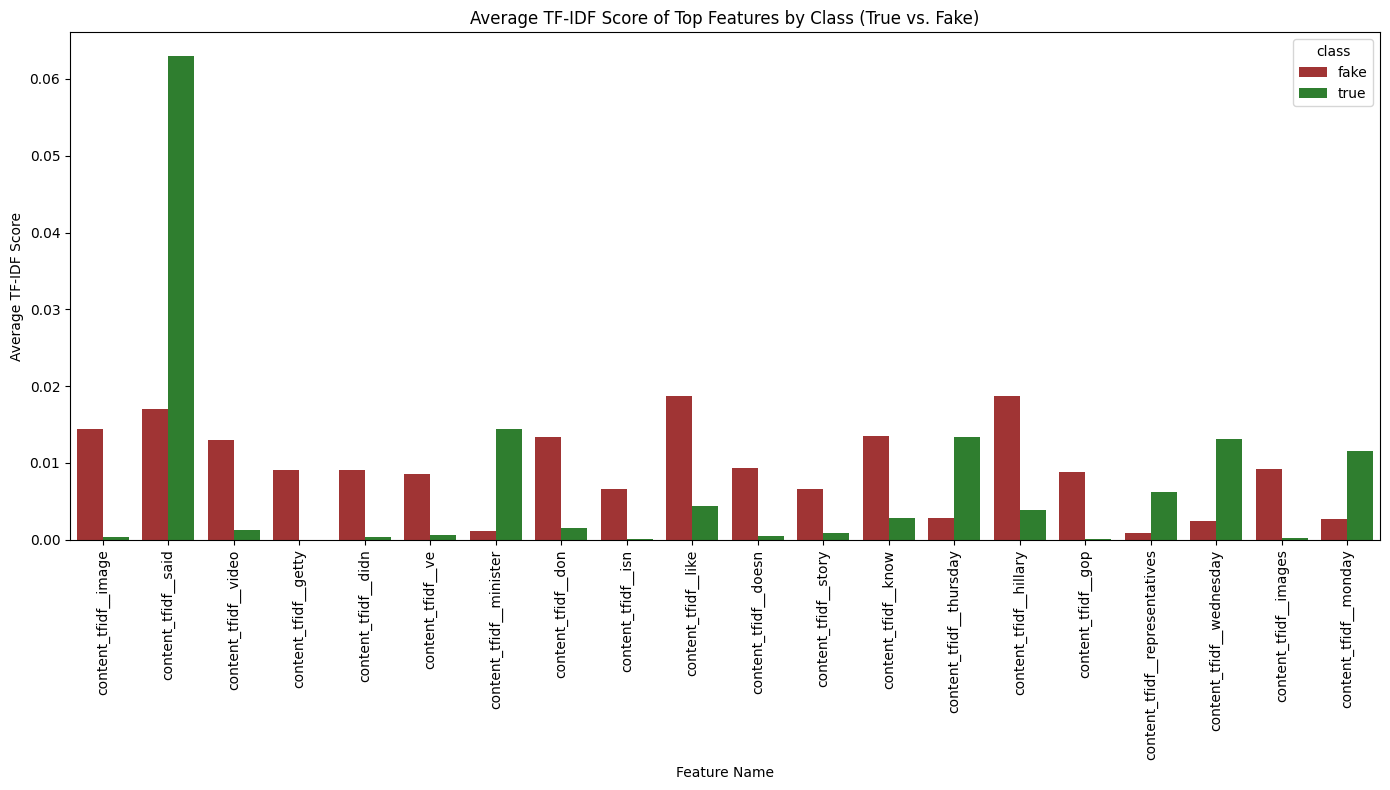

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier manipulation
X_test_df = pd.DataFrame(X_test.toarray(), columns=feature_names)

# Filter for top features
X_test_top_features = X_test_df[top_features]
X_test_top_features['label'] = y_test

# Calculate mean TF-IDF for each class
mean_tfidf_by_class = X_test_top_features.groupby('label')[top_features].mean()

# Prepare data for plotting
plot_data = mean_tfidf_by_class.T.reset_index()
plot_data.columns = ['feature', 'fake', 'true'] # Assuming 0 is fake, 1 is true
plot_data_melted = plot_data.melt(id_vars='feature', var_name='class', value_name='mean_tfidf')

plt.figure(figsize=(14, 8))
sns.barplot(x='feature', y='mean_tfidf', hue='class', data=plot_data_melted, palette={'true': 'forestgreen', 'fake': 'firebrick'})
plt.xticks(rotation=90)
plt.title('Average TF-IDF Score of Top Features by Class (True vs. Fake)')
plt.ylabel('Average TF-IDF Score')
plt.xlabel('Feature Name')
plt.tight_layout()
plt.show()

### Interpretation of Feature Analysis:

Examine the bar chart carefully:

*   **Highly Discriminative Features**: If certain features have a very high average TF-IDF score in one class but a very low score in the other, it indicates they are very discriminative. For example, if a word like 'said' or 'image' has a much higher TF-IDF in 'true' news, it might suggest these are common in formal reporting. Conversely, if words like 'conspiracy' or 'fake_news' appear much higher in the 'fake' class, that's expected.

*   **Potential Artifacts**: If a highly discriminative feature seems *too* specific or like an artifact of how the dataset was constructed (e.g., a specific watermark, formatting term, or a very rare word that happens to only appear in one class due to limited data diversity), it *could* be contributing to overfitting. However, given the earlier checks for subject/dateline leakage, many such obvious artifacts should be gone.

*   **Generalizable vs. Specific Patterns**: A high difference in average TF-IDF values for certain words between classes isn't necessarily a sign of a *bad* data issue, but rather a strong signal. The question is whether this signal is generalizable to new, unseen fake news, or if it's specific to the current dataset's construction or sources.

If the analysis suggests that certain features are overly dominant or potentially artifact-driven, further steps could include:
*   **Feature Engineering**: Trying to create more generalized features or remove highly specific ones.
*   **More Data Augmentation/Collection**: To ensure the model learns from a more diverse set of patterns, reducing reliance on specific artifacts.

### Top 10 Most Discriminative Features for Each Class

Based on the average TF-IDF scores, let's explicitly identify the features that are most strongly associated with each class.

/tmp/ipykernel_1204/3183677165.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_top_features['label'] = y_test


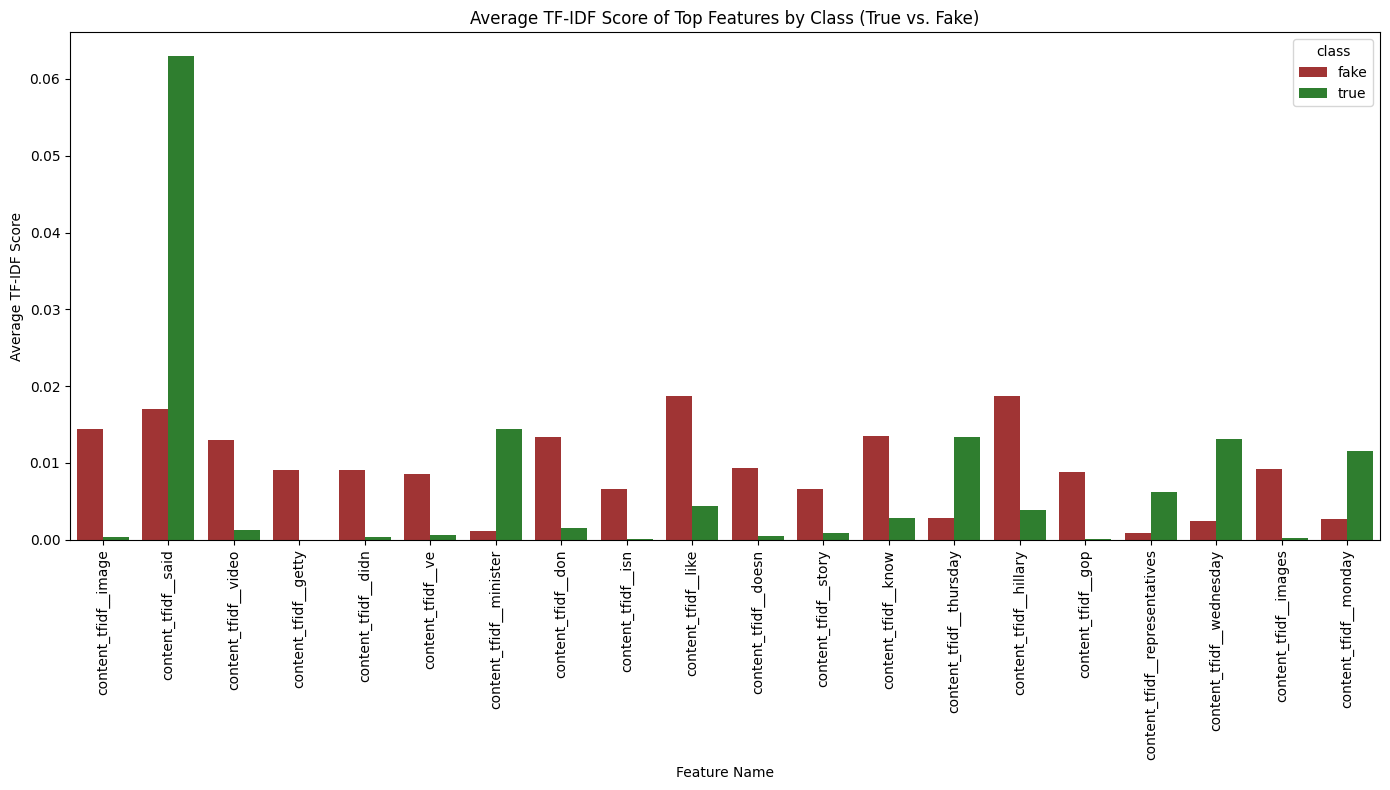

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier manipulation
X_test_df = pd.DataFrame(X_test.toarray(), columns=feature_names)

# Filter for top features
X_test_top_features = X_test_df[top_features]
X_test_top_features['label'] = y_test

# Calculate mean TF-IDF for each class
mean_tfidf_by_class = X_test_top_features.groupby('label')[top_features].mean()

# Prepare data for plotting
plot_data = mean_tfidf_by_class.T.reset_index()
plot_data.columns = ['feature', 'fake', 'true'] # Assuming 0 is fake, 1 is true
plot_data_melted = plot_data.melt(id_vars='feature', var_name='class', value_name='mean_tfidf')

plt.figure(figsize=(14, 8))
sns.barplot(x='feature', y='mean_tfidf', hue='class', data=plot_data_melted, palette={'true': 'forestgreen', 'fake': 'firebrick'})
plt.xticks(rotation=90)
plt.title('Average TF-IDF Score of Top Features by Class (True vs. Fake)')
plt.ylabel('Average TF-IDF Score')
plt.xlabel('Feature Name')
plt.tight_layout()
plt.show()

In [47]:
# Top 10 features for 'true' class (label 1)
top_10_true_features = mean_tfidf_by_class.loc[1].sort_values(ascending=False).head(10)

print("\nTop 10 features for 'True' (Label 1) articles:")
for feature, score in top_10_true_features.items():
    print(f"  {feature:<40} {score:.4f}")

# Top 10 features for 'fake' class (label 0)
top_10_fake_features = mean_tfidf_by_class.loc[0].sort_values(ascending=False).head(10)

print("\nTop 10 features for 'Fake' (Label 0) articles:")
for feature, score in top_10_fake_features.items():
    print(f"  {feature:<40} {score:.4f}")


Top 10 features for 'True' (Label 1) articles:
  content_tfidf__said                      0.0629
  content_tfidf__minister                  0.0145
  content_tfidf__thursday                  0.0134
  content_tfidf__wednesday                 0.0132
  content_tfidf__monday                    0.0116
  content_tfidf__representatives           0.0062
  content_tfidf__like                      0.0044
  content_tfidf__hillary                   0.0039
  content_tfidf__know                      0.0028
  content_tfidf__don                       0.0015

Top 10 features for 'Fake' (Label 0) articles:
  content_tfidf__hillary                   0.0187
  content_tfidf__like                      0.0187
  content_tfidf__said                      0.0170
  content_tfidf__image                     0.0144
  content_tfidf__know                      0.0135
  content_tfidf__don                       0.0134
  content_tfidf__video                     0.0130
  content_tfidf__doesn                     0.0093
  co

## Summary of Overfitting Analysis and Feature Insights

After investigating the high accuracy and the top discriminative features, here's a summary of our findings:

### Observations from Top Features:

*   **'True' Articles (Label 1):** Features like `said`, `minister`, `representatives`, and specific weekdays (`thursday`, `wednesday`, `monday`) are highly associated. This pattern suggests a more formal, structured, and timely reporting style, which is typical for legitimate news sources. The high TF-IDF for 'said' is particularly indicative of reportage.

*   **'Fake' Articles (Label 0):** Features such as `hillary`, `like`, `know`, `don`, `video`, `image`, `doesn`, `images`, `didn` are more prominent. This often points to more colloquial language, references to specific political figures (like 'hillary' potentially indicating a focus of misinformation), and mentions of multimedia content, which can be characteristic of less formal or sensationalized fake news.

### Connecting to Overfitting:

1.  **Highly Discriminative is Not Always Overfitting:** The stark differences in features between classes are not necessarily a problem. Instead, they indicate that the 'true' and 'fake' articles in this dataset possess distinct writing styles and content patterns. The models are effectively learning these strong, inherent differences.

2.  **Training vs. Test Accuracy Gap:** We observed a small but consistent gap between training and test accuracy across most models (e.g., SVM train accuracy ~0.999 vs. test accuracy ~0.981; RF train accuracy ~0.996 vs. test accuracy ~0.969). This gap **does** suggest some degree of overfitting, meaning the models learned the training data slightly too well. However, the test accuracy remains very high, implying good generalization to unseen data *from the same distribution*.

3.  **Cross-Validation Robustness:** The cross-validation for the SVM model (with a mean accuracy of ~0.983 and a very low standard deviation) confirmed that the model's performance is robust and generalizes well across different subsets of this particular dataset.

### Overall Conclusion:

The high accuracy observed in the models appears to stem primarily from the strong and consistent stylistic and content differences between the 'true' and 'fake' news articles within this dataset. While there's a minor indication of overfitting from the training-test accuracy gap, the robust cross-validation scores suggest that the models are indeed generalizing well. The identified discriminative features provide valuable insight into these underlying differences. For example, the prominence of 'hillary' in fake news features suggests that misinformation in this dataset might have focused on particular individuals. This is a real pattern, but it's important to consider if such specific features would generalize to entirely new topics or individuals in future fake news detection tasks.